In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

In [3]:
df = pd.read_csv("framingham.csv")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
#############################################################################
#
# Data Cleaning
#
#####################

In [7]:
print(df.isnull().sum())
print(df.duplicated().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
0


In [8]:
df['glucose'] = df['glucose'].fillna(df['glucose'].median())

for col in ['cigsPerDay', 'BPMeds', 'totChol', 'BMI', 'heartRate', 'education']:
    df[col] = df[col].fillna(df[col].median())
 
print("Missing values after cleaning:")
print(df.isnull().sum())
 

Missing values after cleaning:
male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [ ]:
#############################################################################
#
# EDA
#
#####################

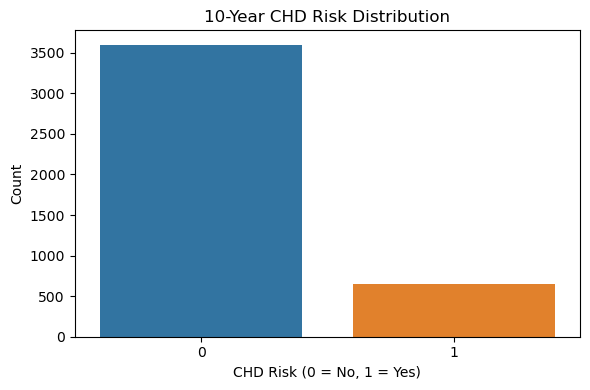

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='TenYearCHD', data=df)
plt.title("10-Year CHD Risk Distribution")
plt.xlabel("CHD Risk (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
 
print("Numeric columns:", numeric_cols)
print("\nCategorical columns:", categorical_cols)
 

Numeric columns: ['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

Categorical columns: []


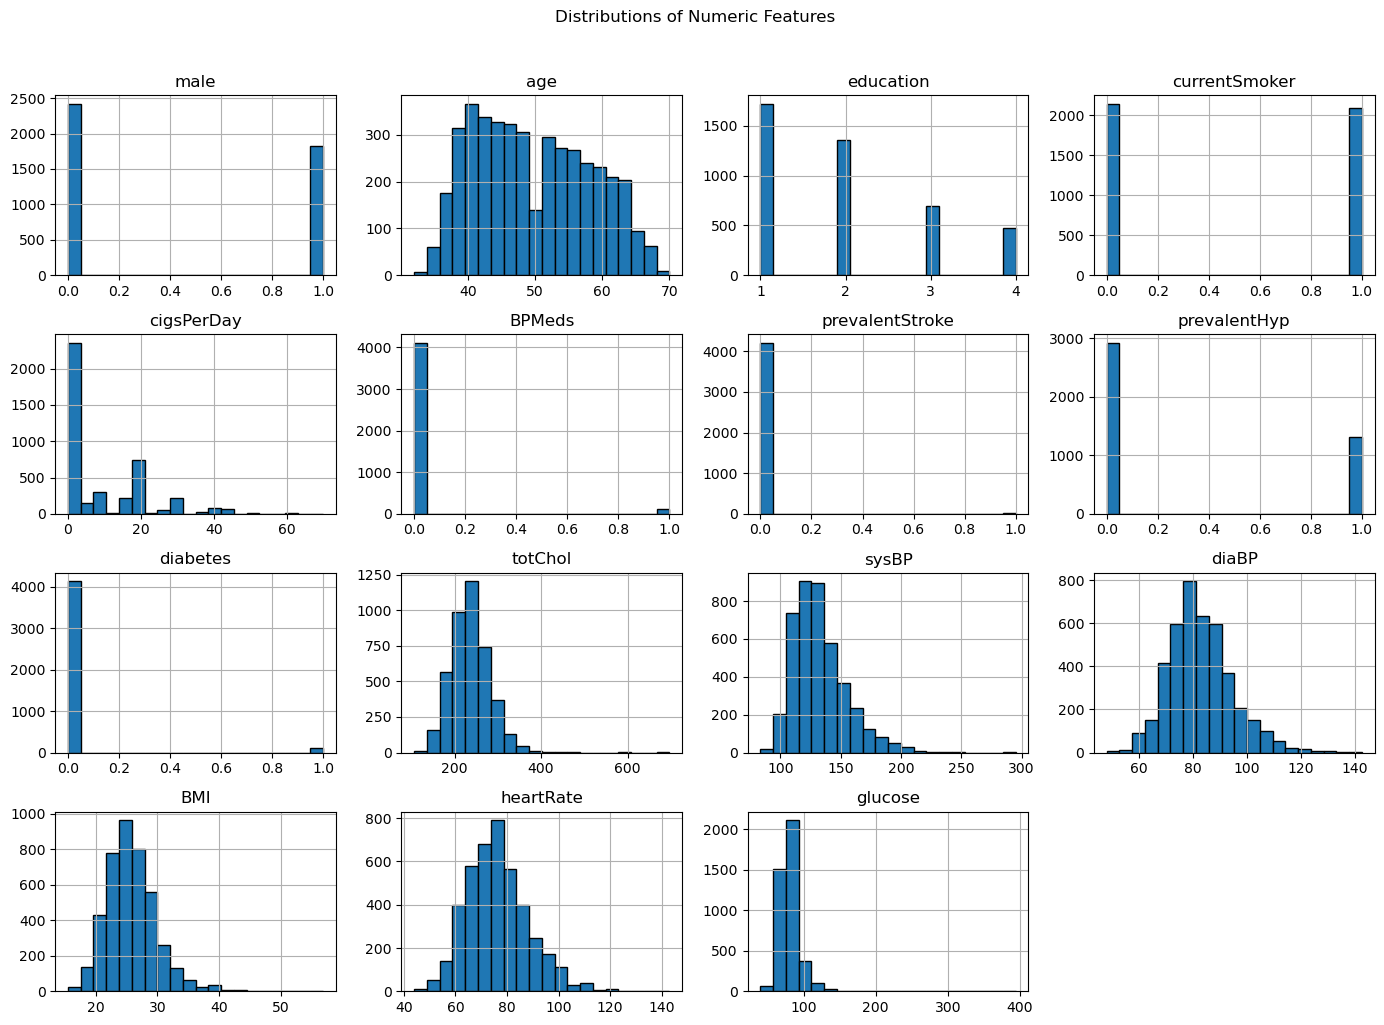

In [18]:
numeric_eda_cols = [col for col in numeric_cols if col not in ["TenYearCHD"]]
 
df[numeric_eda_cols].hist(figsize=(14, 10), bins=20, edgecolor="black")
plt.suptitle("Distributions of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

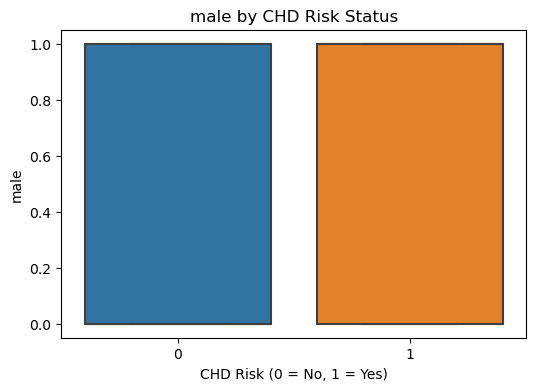

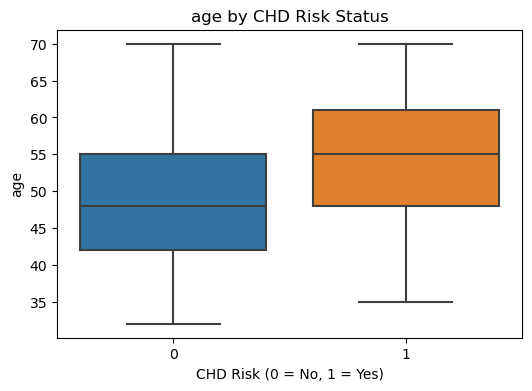

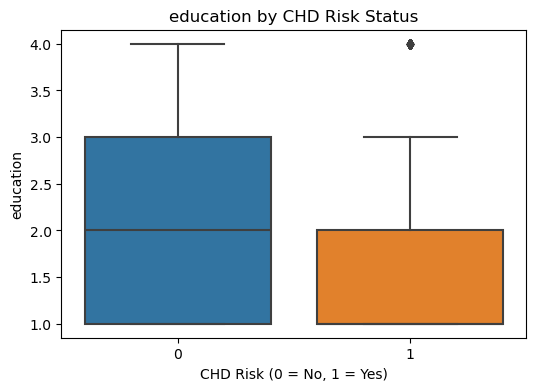

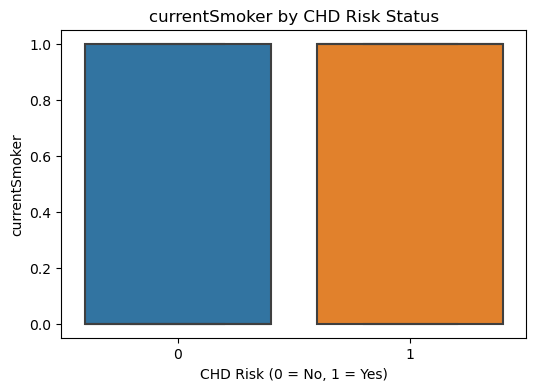

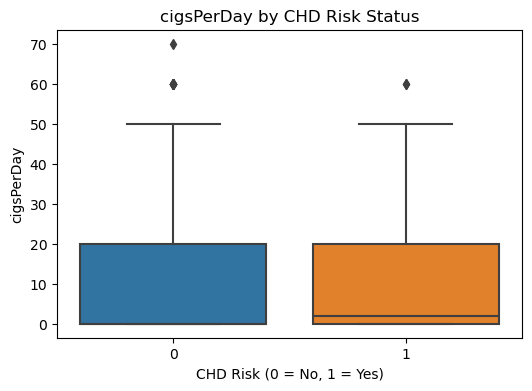

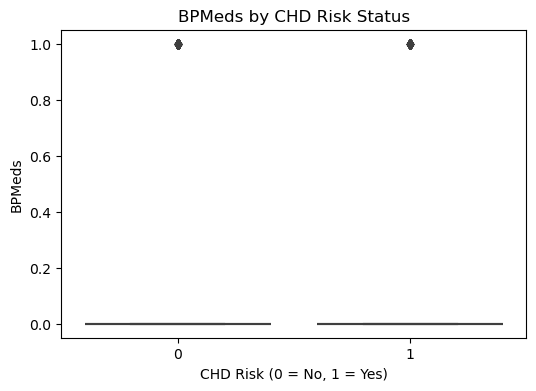

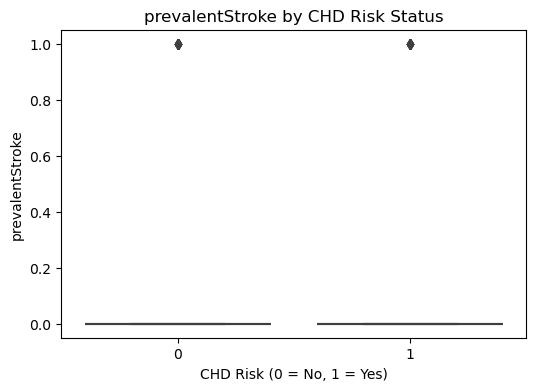

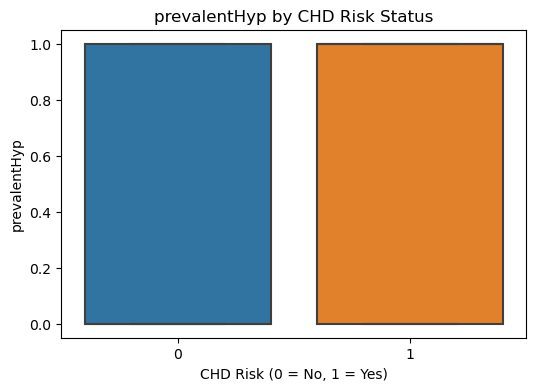

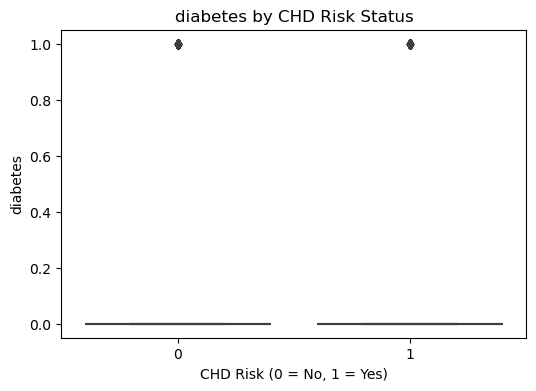

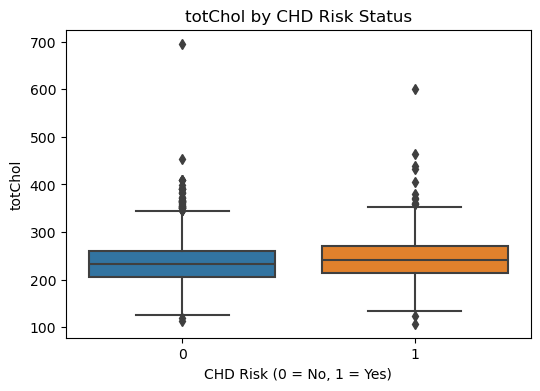

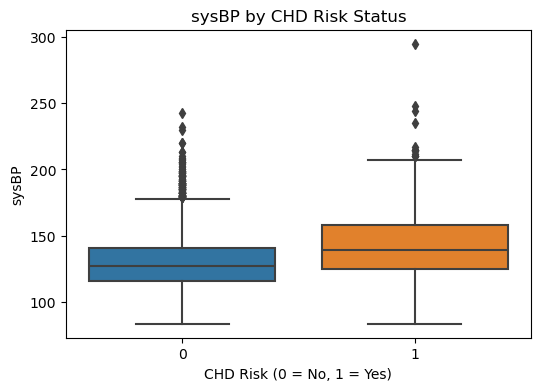

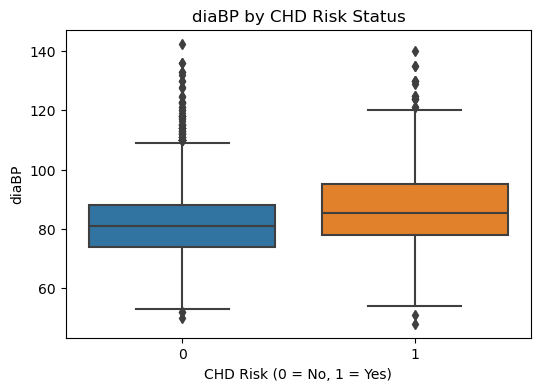

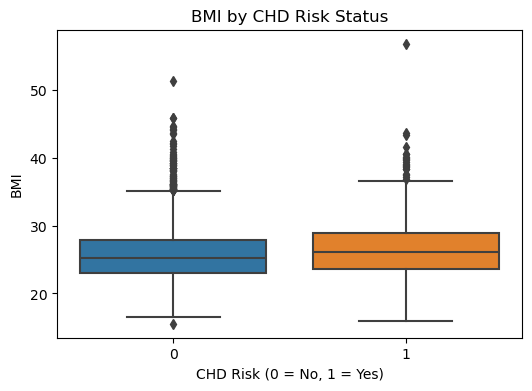

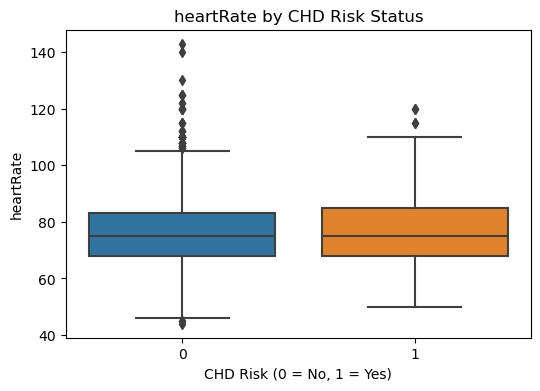

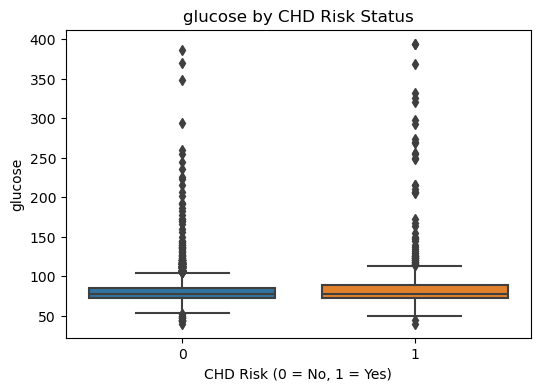

In [19]:
for col in numeric_eda_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="TenYearCHD", y=col)
    plt.title(f"{col} by CHD Risk Status")
    plt.xlabel("CHD Risk (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.show()

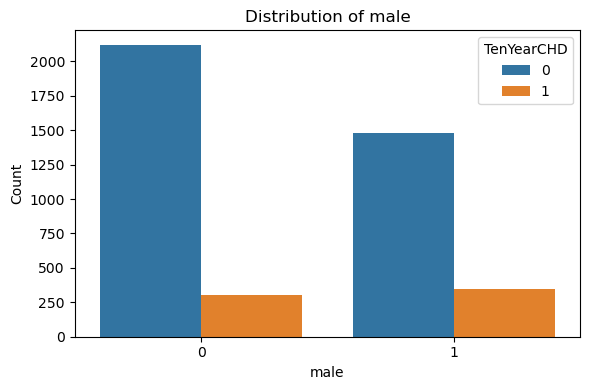

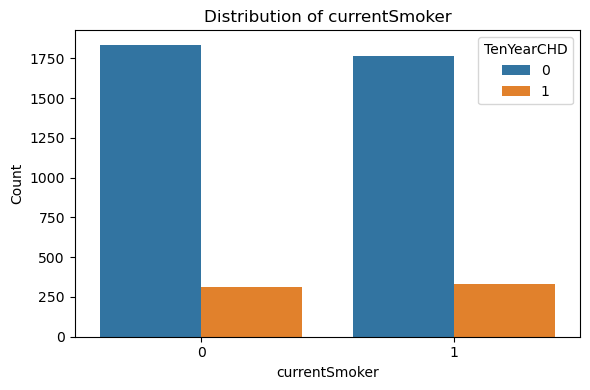

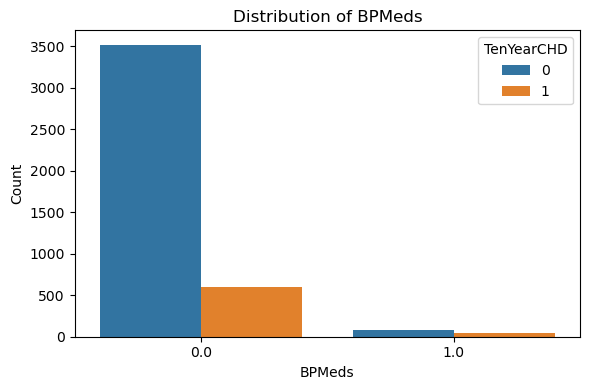

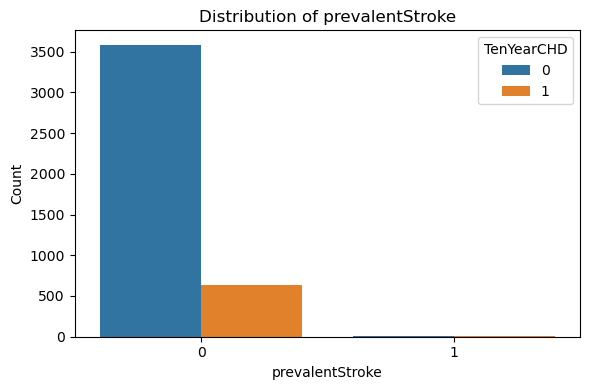

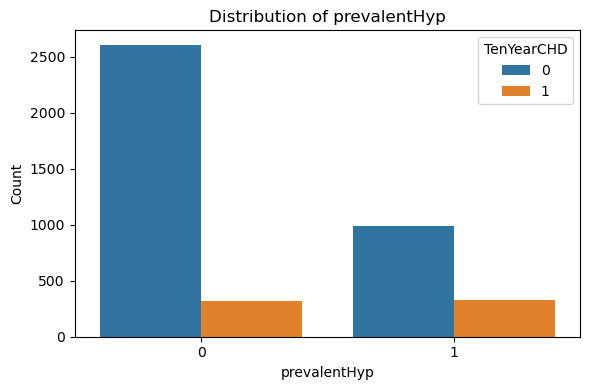

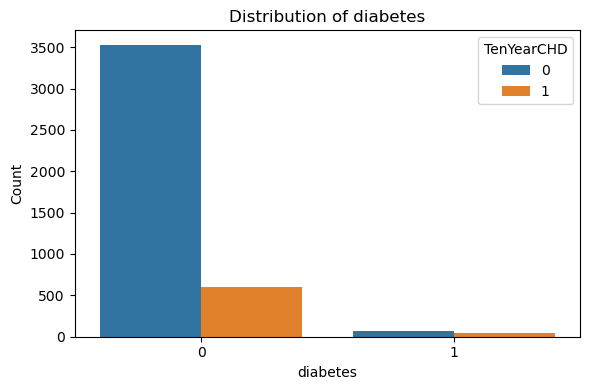

In [21]:
binary_cols = ['male', 'currentSmoker', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes']
 
for col in binary_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col, hue='TenYearCHD', order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

                     male       age  education  currentSmoker  cigsPerDay  \
male             1.000000 -0.029014   0.017265       0.197026    0.314849   
age             -0.029014  1.000000  -0.164016      -0.213662   -0.192017   
education        0.017265 -0.164016   1.000000       0.018270    0.007856   
currentSmoker    0.197026 -0.213662   0.018270       1.000000    0.760326   
cigsPerDay       0.314849 -0.192017   0.007856       0.760326    1.000000   
BPMeds          -0.051544  0.121011  -0.010445      -0.048348   -0.044697   
prevalentStroke -0.004550  0.057679  -0.035178      -0.032980   -0.032248   
prevalentHyp     0.005853  0.306799  -0.080780      -0.103710   -0.065541   
diabetes         0.015693  0.101314  -0.038204      -0.044285   -0.036173   
totChol         -0.069643  0.260527  -0.022851      -0.046391   -0.027134   
sysBP           -0.035879  0.394053  -0.128139      -0.130281   -0.088393   
diaBP            0.058199  0.205586  -0.061326      -0.107933   -0.056768   

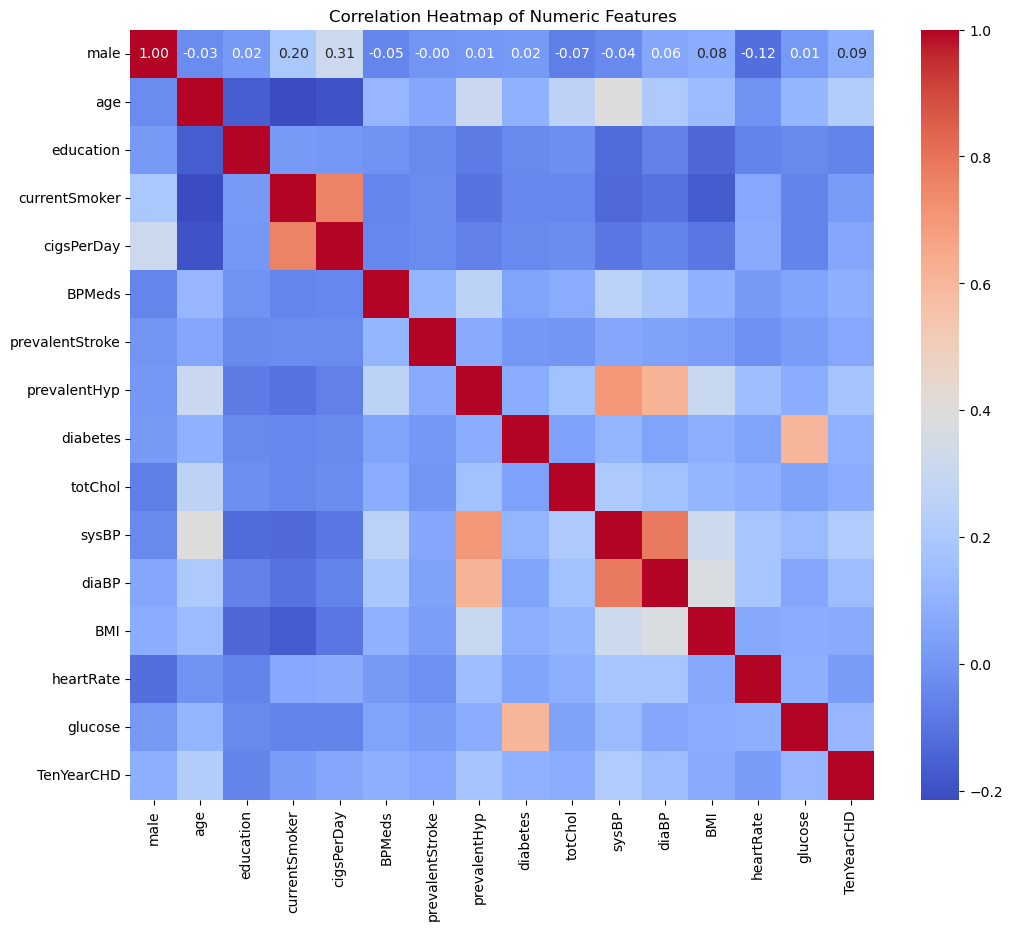

In [23]:
corr_matrix = df[[col for col in numeric_cols]].corr()
print(corr_matrix)
 
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [25]:
corr_matrix2 = df.corr()
chd_corr = corr_matrix2["TenYearCHD"].sort_values(ascending=False)
 
print(chd_corr)

TenYearCHD         1.000000
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.121319
diabetes           0.097344
male               0.088374
BPMeds             0.086448
totChol            0.081749
BMI                0.074326
prevalentStroke    0.061823
cigsPerDay         0.058729
heartRate          0.022851
currentSmoker      0.019448
education         -0.053570
Name: TenYearCHD, dtype: float64


In [ ]:
# #############################################################################
# #
# # Preprocessing
# #
# #####################

In [26]:
y = df["TenYearCHD"]
X = df.drop(columns=["TenYearCHD"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3392, 15)
Test shape: (848, 15)


In [ ]:
# #############################################################################
# #
# # Train ML Models
# #
# ####################

In [27]:
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [28]:
scorers = {'Accuracy': 'accuracy', 'roc_auc': 'roc_auc', 'F1': 'f1'}

In [29]:
# ================================
# Model 1 — Logistic Regression
# ================================
 
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
scores_lr = cross_validate(estimator=log_model, X=X_train_scaled, y=y_train, scoring=scorers, cv=5)
 
print("Logistic Regression:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_lr['test_Accuracy'].mean(), scores_lr['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_lr['test_roc_auc'].mean(),  scores_lr['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_lr['test_F1'].mean(),       scores_lr['test_F1'].std()       * 2))
 
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
 
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_log, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_log, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression:
Acc: 0.67 (+/- 0.04)
AUC: 0.73 (+/- 0.05)
F1:  0.38 (+/- 0.07)
Accuracy: 0.6721698113207547
Precision: 0.25412541254125415
Recall: 0.5968992248062015
F1 Score: 0.35648148148148145
ROC-AUC: 0.7005207491024356
Confusion Matrix:
[[493 226]
 [ 52  77]]


In [30]:
# ================================
# Model 2 — Decision Tree
# ================================
 
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
scores_dt = cross_validate(estimator=dt_model, X=X_train, y=y_train, scoring=scorers, cv=5)
 
print("Decision Tree:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_dt['test_Accuracy'].mean(), scores_dt['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_dt['test_roc_auc'].mean(),  scores_dt['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_dt['test_F1'].mean(),       scores_dt['test_F1'].std()       * 2))
 
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]
 
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_dt, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
 

Decision Tree:
Acc: 0.63 (+/- 0.13)
AUC: 0.66 (+/- 0.03)
F1:  0.33 (+/- 0.03)
Accuracy: 0.6698113207547169
Precision: 0.23693379790940766
Recall: 0.5271317829457365
F1 Score: 0.3269230769230769
ROC-AUC: 0.6596370928615325
Confusion Matrix:
[[500 219]
 [ 61  68]]


In [31]:
# ================================
# Model 3:  Random Forest
# ================================
 
rf_model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=3, criterion="entropy", random_state=42, class_weight="balanced")
scores_rf = cross_validate(estimator=rf_model, X=X_train, y=y_train, scoring=scorers, cv=5)
 
print("Random Forest:")
print("Acc: %0.2f (+/- %0.2f)" % (scores_rf['test_Accuracy'].mean(), scores_rf['test_Accuracy'].std() * 2))
print("AUC: %0.2f (+/- %0.2f)" % (scores_rf['test_roc_auc'].mean(),  scores_rf['test_roc_auc'].std()  * 2))
print("F1:  %0.2f (+/- %0.2f)" % (scores_rf['test_F1'].mean(),       scores_rf['test_F1'].std()       * 2))
 
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
 
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rf, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
 

Random Forest:
Acc: 0.85 (+/- 0.01)
AUC: 0.71 (+/- 0.04)
F1:  0.09 (+/- 0.07)
Accuracy: 0.8431603773584906
Precision: 0.35714285714285715
Recall: 0.03875968992248062
F1 Score: 0.06993006993006992
ROC-AUC: 0.6464835958641955
Confusion Matrix:
[[710   9]
 [124   5]]


age                0.148744
sysBP              0.135225
BMI                0.120750
totChol            0.120282
diaBP              0.111954
glucose            0.110894
heartRate          0.098130
cigsPerDay         0.049410
education          0.037161
male               0.020908
prevalentHyp       0.019086
currentSmoker      0.012488
diabetes           0.006557
BPMeds             0.005593
prevalentStroke    0.002818
dtype: float64

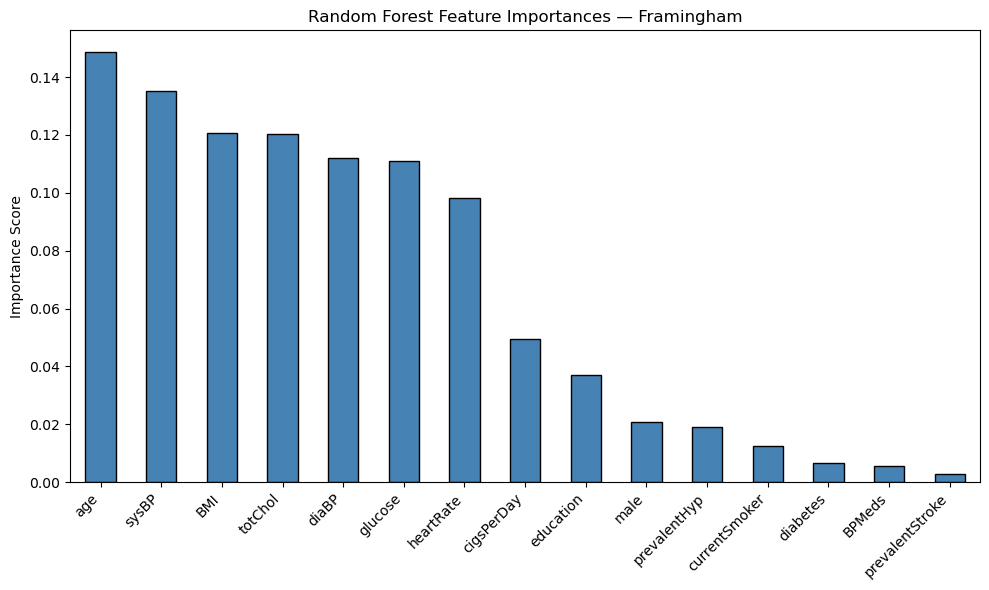

In [32]:
 
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
 
display(importances)
 
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Random Forest Feature Importances — Framingham")
plt.ylabel("Importance Score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# #############################################################################
# #
# # Model Comparison
# #
# #####################

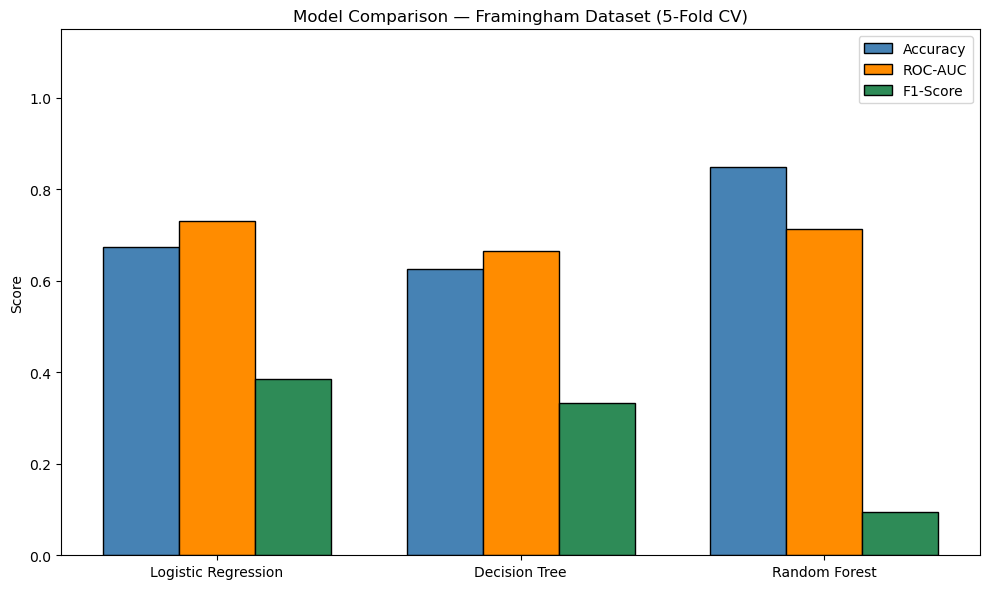

In [33]:
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
cv_acc = [scores_lr['test_Accuracy'].mean(), scores_dt['test_Accuracy'].mean(), scores_rf['test_Accuracy'].mean()]
cv_auc = [scores_lr['test_roc_auc'].mean(),  scores_dt['test_roc_auc'].mean(),  scores_rf['test_roc_auc'].mean()]
cv_f1  = [scores_lr['test_F1'].mean(),       scores_dt['test_F1'].mean(),       scores_rf['test_F1'].mean()]
 
x = np.arange(len(model_names))
width = 0.25
 
plt.figure(figsize=(10, 6))
plt.bar(x - width, cv_acc, width, label='Accuracy',  color='steelblue',  edgecolor='black')
plt.bar(x,         cv_auc, width, label='ROC-AUC',   color='darkorange', edgecolor='black')
plt.bar(x + width, cv_f1,  width, label='F1-Score',  color='seagreen',   edgecolor='black')
plt.xticks(x, model_names)
plt.ylim(0, 1.15)
plt.ylabel('Score')
plt.title('Model Comparison — Framingham Dataset (5-Fold CV)')
plt.legend()
plt.tight_layout()
plt.show()

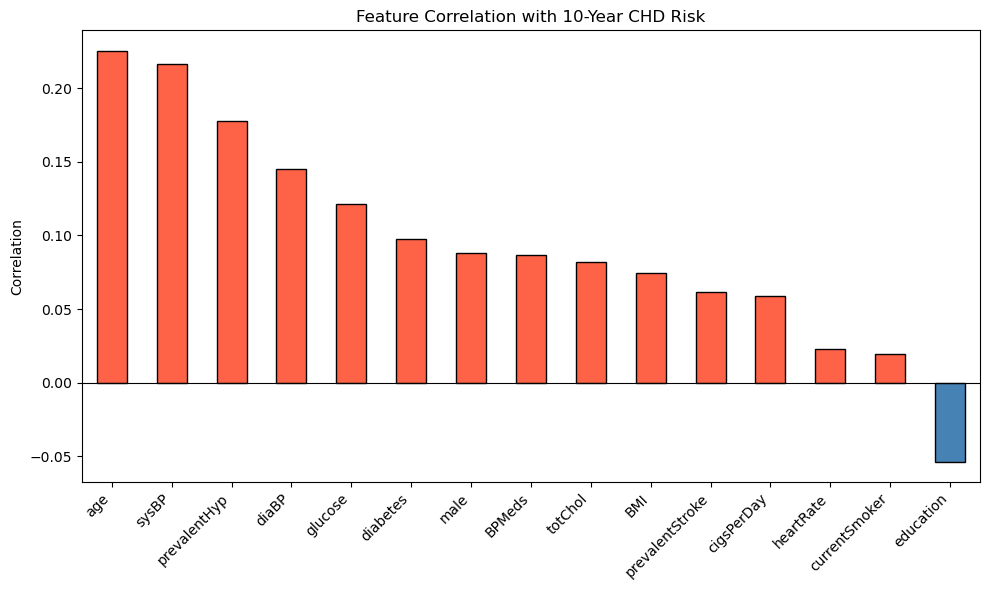

In [35]:
# Correlation with target — bar chart
chd_corr = corr_matrix2["TenYearCHD"].drop("TenYearCHD").sort_values(ascending=False)

plt.figure(figsize=(10, 6))
chd_corr.plot(kind='bar', color=['tomato' if x > 0 else 'steelblue' for x in chd_corr],
              edgecolor='black')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title("Feature Correlation with 10-Year CHD Risk")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()